# QFI for Collective Spins — N = 2 Homodyne Dephasing

## Physical motivation

We study $N = 2$ two-level atoms under **independent z-dephasing**, whose unconditional master equation is
$$
\dot{\rho} = \frac{\gamma}{2}\sum_{k=1}^{2} \mathcal{D}[\sigma_z^{(k)}]\rho,
\qquad
\mathcal{D}[L]\rho = L\rho L^\dagger - \tfrac{1}{2}\{L^\dagger L, \rho\}.
$$

When the environment is monitored via **homodyne detection**, the evolution is replaced by a stochastic master equation (SME) for the *conditional* state $\rho_c(t)$.  The SME depends on:
- the decay rate $\gamma$;
- the local measurement phases $\phi_1, \phi_2$;
- the detection efficiencies $\eta_1, \eta_2 \in [0,1]$.

Perfectly efficient monitoring ($\eta = 1$) keeps the state pure at all times: $\rho_c(t) = |\psi_c(t)\rangle\langle\psi_c(t)|$.

## What we compute

For each conditional state we track:

| Symbol | Meaning |
|--------|---------|
| $\|\langle\mathbf{J}\rangle\|$ | Length of the mean-spin vector (MSD) |
| $\xi^2_{KU}$ | Kitagawa–Ueda spin-squeezing parameter |
| $\xi^2_{W}$ | Wineland spin-squeezing parameter |
| $F_Q^{\max}$ | Optimal QFI over all collective-spin generators |
| $\chi^2 = N/F_Q^{\max}$ | Metrological gain (< 1 beats SQL) |
| $\mathrm{Var}(J_z)$ | Variance of the z-component |
| $\langle\Pi_z\rangle$ | Parity $\langle\sigma_z^{(1)}\sigma_z^{(2)}\rangle$ |
| $\mathrm{Tr}(\rho_c^2)$ | Purity of the conditional state |

## Notebook outline

1. **Setup** — reproduce the `main_SLURM.py` conventions  
2. **Pure-state QFI** — $F_Q = 4\,\mathrm{Var}(G)$, optimal axis  
3. **Ideal trajectories** ($\eta_1 = \eta_2 = 1$, `ntraj = 30`) — per-trajectory plots, ensemble mean ± std, final-time histograms  
4. **Mixed-state QFI** — SLD formula, consistency check  
5. **Phase scan** — vary $\phi_1 \in \{0,\frac{\pi}{4},\frac{\pi}{2},\pi\}$, track ensemble QFI  
6. **Efficiency scan** — $\eta \in \{1.0, 0.8, 0.6, 0.4\}$, purity decay, metrological gain comparison  
7. **Comparison** — trajectory mean vs. mean state ($\eta = 0.5$)  
8. **QFI vs spin squeezing** — scatter $F_Q^{\max}$ vs $\xi^2_W$  


In [21]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from qutip import basis, expect, ket2dm, qeye, sigmax, sigmay, sigmaz, smesolve, tensor, variance

# TeX / font settings (same as main_SLURM.py)
plt.rcParams["text.usetex"] = True
plt.rcParams.update(
    {
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.size": 14,
        "axes.unicode_minus": False,
    }
)

## 1. Setup — N = 2 conventions from `main_SLURM.py`

We keep exactly the same conventions as the simulation script to ensure direct comparability.

**Basis:** $|g\rangle = |0\rangle$, $|e\rangle = |1\rangle$, so $|+\rangle = (|0\rangle + |1\rangle)/\sqrt{2}$.

**Initial state:** $|\psi_0\rangle = |{+}{+}\rangle$, a coherent spin state (CSS) along $x$ with $\langle J_x\rangle = 1$, $\langle J_{y,z}\rangle = 0$.

**Homodyne channels** (Gram–Schmidt of the local dephasing operators):
$$
C_\pm = \frac{1}{\sqrt{2}}\bigl(\sigma_z^{(1)} \pm \sigma_z^{(2)}\bigr).
$$
$C_+$ is the *symmetric* (collective) channel; $C_-$ is the *antisymmetric* one.

**Collapsing operators** with phase and efficiency:
$$
L_\pm = \sqrt{\gamma\,\eta_\pm}\,e^{i\phi_\pm}\,C_\pm.
$$
The unmonitored fraction enters `c_ops` with weight $\sqrt{\gamma(1-\eta)}$.

**Free Hamiltonian:** $H = 0$ (no precession) so decoherence dominates.

**Parity operator:** $\Pi_z = \sigma_z^{(1)}\otimes\sigma_z^{(2)}$, which distinguishes the even Bell sector $\{|\Phi^\pm\rangle\}$ from the odd sector $\{|\Psi^\pm\rangle\}$.


In [22]:
# Stesse convenzioni di main_SLURM.py — le funzioni di spin squeezing sono
# reimplementate localmente per rendere il notebook self-contained e per
# evitare che l'import di main_SLURM.py (che chiama matplotlib.use("Agg"))
# sovrascriva il backend inline di Jupyter.
N_SPIN = 2
DT = 0.001
T_END = 5.0

gnd = basis(2, 0)
exc = basis(2, 1)

#Convenzione
plus_state = (gnd + exc).unit()
#Stato |++>
psi0 = tensor(plus_state, plus_state)
rho0 = ket2dm(psi0)

#Identita, operatore di spin e liste
I_2 = qeye(2)
J_x = 0.5 * (tensor(sigmax(), I_2) + tensor(I_2, sigmax()))
J_y = 0.5 * (tensor(sigmay(), I_2) + tensor(I_2, sigmay()))
J_z = 0.5 * (tensor(sigmaz(), I_2) + tensor(I_2, sigmaz()))
#Operatore di parita lungo z per N=2
Pi_z = tensor(sigmaz(), sigmaz())

SPIN_OPS = [J_x, J_y, J_z]
SPIN_LABELS = ["J_x", "J_y", "J_z"]
#Colonne che vogliamo tracciare step by step nello stato condizionato
OBSERVABLE_COLUMNS = [
    "Norm_J",
    "Xi2_KU",
    "Xi2_WIN",
    "QFI_max",
    "chi_square",
    "Var_Jz",
    "Parity_Pi_z",
]
#Componenti dell'asse ottimale che massimizza la QFI
AXIS_COLUMNS = ["axis_x", "axis_y", "axis_z"]

#Base per i collapsing operators
Cp = np.sqrt(0.5) * (tensor(sigmaz(), I_2) + tensor(I_2, sigmaz()))
Cm = np.sqrt(0.5) * (tensor(sigmaz(), I_2) - tensor(I_2, sigmaz()))

#Hamiltoniana come al solito posta a zero, in quanto stiamo considerando solo il processo di decoerenza
H_free = 0 * J_z

#Collapsing operators con parametri di decoerenza, fasi ed efficienze
def collapsing_operators(gamma, phi_1, phi_2, eta_1, eta_2):
    return [
        np.sqrt(gamma * eta_1) * np.exp(1j * phi_1) * Cp,
        np.sqrt(gamma * eta_2) * np.exp(1j * phi_2) * Cm,
    ]

# -------------------------------------------------------------------------
# Spin-squeezing helpers: norm_J, xi_KU_solver, xi_WIN_solver
# Identici a main_SLURM.py ma definiti localmente per evitare il side-effect
# dell'import (matplotlib.use("Agg") sovrascrive il backend inline).
# -------------------------------------------------------------------------

def eval_spin_components(state):
    return expect(J_x, state), expect(J_y, state), expect(J_z, state)

def norm_J(t, rho):
    return np.linalg.norm(eval_spin_components(rho))

def xi_KU_solver(t, rho, N=None, tol=1e-12):
    """
    Parametro di Kitagawa-Ueda:
        xi^2_KU = (4/N) * lambda_min(C_perp)
    C_perp = matrice di covarianza proiettata sul piano ortogonale a <J>.
    Se |<J>| = 0 (es. stati di Bell), lambda_min e' calcolato su tutto R^3.
    """
    if N is None:
        N = N_SPIN
    Jx_exp, Jy_exp, Jz_exp = eval_spin_components(rho)
    Jmean = np.array([float(np.real_if_close(x)) for x in [Jx_exp, Jy_exp, Jz_exp]])
    m = np.linalg.norm(Jmean)

    #Matrice di covarianza 3x3: C_ij = 1/2 <{Ji, Jj}> - <Ji><Jj>
    C = np.zeros((3, 3), dtype=float)
    for i, Ji in enumerate(SPIN_OPS):
        for j, Jj in enumerate(SPIN_OPS):
            second_moment = 0.5 * expect(Ji * Jj + Jj * Ji, rho)
            C[i, j] = float(np.real_if_close(second_moment - Jmean[i] * Jmean[j]))

    if m > tol:
        u = Jmean / m
        a = np.array([1.0, 0.0, 0.0]) if abs(u[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
        #Gram-Schmidt: e1, e2 formano una base del piano perpendicolare a u
        e1 = a - u * np.dot(u, a); e1 /= np.linalg.norm(e1)
        e2 = np.cross(u, e1)
        C2 = np.array([[e1 @ C @ e1, e1 @ C @ e2],
                        [e2 @ C @ e1, e2 @ C @ e2]], dtype=float)
        lam_min = np.linalg.eigvalsh(C2)[0]
    else:
        lam_min = np.linalg.eigvalsh(C)[0]

    lam_min = max(float(np.real_if_close(lam_min)), 0.0)
    return float((4.0 / N) * lam_min)

def xi_WIN_solver(t, rho, N=None, tol=1e-12):
    """
    Parametro di Wineland:
        xi^2_WIN = xi^2_KU * (N/2 / |<J>|)^2
    xi^2_WIN < 1 indica vantaggio metrologico rispetto ai CSS.
    """
    if N is None:
        N = N_SPIN
    norm = np.linalg.norm(eval_spin_components(rho))
    xi_ku = xi_KU_solver(t, rho, N=N)
    return xi_ku * ((N / 2.0) / norm) ** 2 if norm > tol else xi_ku

# Cartella di output per i grafici
from pathlib import Path
OUT_DIR = Path("./Graphs/QFI_notebook")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUT_DIR.resolve()}")

Output directory: C:\Users\staka\OneDrive\Desktop\Figlio\Stochastic_Master_Thesis\Codes\Graphs\QFI_notebook


## 2. Pure-state QFI and the Cramér–Rao bound

### Quantum Fisher Information

For a unitary family $|\psi_\lambda\rangle = e^{-i\lambda G}|\psi\rangle$ with generator $G$, the QFI is
$$
F_Q[|\psi\rangle, G] = 4\,\mathrm{Var}_\psi(G) = 4\bigl(\langle G^2\rangle - \langle G\rangle^2\bigr).
$$

The **quantum Cramér–Rao bound** states that any unbiased estimator $\hat\lambda$ of $\lambda$ satisfies
$$
\mathrm{Var}(\hat\lambda) \geq \frac{1}{m\,F_Q},
$$
where $m$ is the number of repetitions.

### Heisenberg limit and SQL

For a collective-spin generator $J_n = n_x J_x + n_y J_y + n_z J_z$ and $N$ spin-$\tfrac{1}{2}$ particles:
- **Standard Quantum Limit (SQL):** $F_Q = N$ (coherent spin states);
- **Heisenberg Limit (HL):** $F_Q = N^2$ (maximally entangled states, e.g. GHZ).

For $N = 2$: SQL $= 2$, HL $= 4$. The CSS $|{+}{+}\rangle$ saturates the SQL along any axis orthogonal to $x$.

### Optimal axis

Since $F_Q[|\psi\rangle, J_n] = n^\top \mathbf{F}\, n$ where $\mathbf{F}_{ab} = 4\,\mathrm{Cov}(J_a, J_b)$, the maximum QFI and optimal axis are found by diagonalizing the $3\times 3$ matrix $\mathbf{F}$:
$$
F_Q^{\max} = \lambda_{\max}(\mathbf{F}), \qquad n^* = \text{corresponding eigenvector}.
$$

### Metrological gain

We define $\chi^2 \equiv N/F_Q^{\max}$. Spin squeezing implies $\xi^2_W < 1$, which is equivalent to sub-SQL sensitivity ($\chi^2 < 1$) when the mean-spin direction is used as the sensing axis.


In [23]:
#Funzioni per il calcolo della QFI e delle quantita da salvare nei DataFrame

# Normalizzazione dell'asse di rotazione
# Questa funzione prende un asse di rotazione (un vettore) e lo normalizza, restituendo un vettore unitario.
def normalize_axis(axis):
    axis = np.asarray(axis, dtype=float)
    norm = np.linalg.norm(axis)
    if norm <= 0:
        raise ValueError("The axis must be non-zero.")
    return axis / norm

# Generatore collettivo a partire da un asse di rotazione
# Questa funzione prende un asse di rotazione normalizzato e restituisce il generatore collettivo
def collective_generator_from_axis(axis):
    n = normalize_axis(axis)
    return n[0] * J_x + n[1] * J_y + n[2] * J_z

# Calcolo della QFI per uno stato puro e un generatore dato
#E' semplicemente 4 volte la varianza del generatore rispetto allo stato puro
def pure_state_qfi(psi, G):
    return float(np.real_if_close(4.0 * variance(G, psi)))

# Calcolo della QFI lungo un asse di rotazione specificato
def pure_qfi_along_axis(psi, axis):
    return pure_state_qfi(psi, collective_generator_from_axis(axis))

# Calcolo della matrice di QFI per uno stato puro
# Restituisce la matrice di QFI contiente le varianze e covarianze dei generatori di rotazione rispetto allo stato puro
def pure_qfi_matrix(psi):
    means = np.array([expect(op, psi) for op in SPIN_OPS], dtype=complex)
    cov = np.zeros((3, 3), dtype=float)
    for a, Ja in enumerate(SPIN_OPS):
        for b, Jb in enumerate(SPIN_OPS):
            sym = 0.5 * expect(Ja * Jb + Jb * Ja, psi)
            cov[a, b] = float(np.real_if_close(sym - means[a] * means[b]))
    return 4.0 * cov

#Dalla matrice di QFI, calcola il massimo autovalore e l'autovettore corrispondente, che rappresenta l'asse ottimale di rotazione
def pure_optimal_axis_qfi(psi):
    F = pure_qfi_matrix(psi)
    eigvals, eigvecs = np.linalg.eigh(F)
    idx = int(np.argmax(eigvals))
    axis = eigvecs[:, idx]
    # Convenzione di segno: la componente di modulo massimo e' positiva
    idx_max = int(np.argmax(np.abs(axis)))
    if axis[idx_max] < 0:
        axis = -axis
    return float(eigvals[idx]), normalize_axis(axis), F

#Se lo stato arriva come ket, lo trasformiamo in matrice densita
def state_as_dm(state):
    return ket2dm(state) if state.isket else state

# -------------------------------------------------------------------------
# QFI per stati misti — formula SLD (Symmetric Logarithmic Derivative)
#
#   F_Q[rho, G] = 2 * sum_{p_i + p_j > 0} (p_i - p_j)^2 / (p_i + p_j) * |<i|G|j>|^2
#
# dove {p_i, |i>} sono autovalori e autovettori di rho.
# Per stati puri (rank 1), la formula si riduce esattamente a 4 Var(G):
#   termini non nulli: (0,k) e (k,0) con p_0=1, p_{k>0}=0
#   coeff = 2*(1-0)^2/(1+0) = 2 per ciascuno
#   totale = 4 * sum_{k>0} |<0|G|k>|^2 = 4*(<G^2> - <G>^2) = 4 Var(G)  checkmark
# -------------------------------------------------------------------------

#Formula generale della QFI per stati misti
def mixed_state_qfi(rho, G, tol=1e-12):
    rho = state_as_dm(rho)
    evals, ekets = rho.eigenstates()
    qfi = 0.0
    for i, p_i in enumerate(evals):
        p_i = float(np.real_if_close(p_i))
        for j, p_j in enumerate(evals):
            p_j = float(np.real_if_close(p_j))
            denom = p_i + p_j
            if denom <= tol:
                continue
            G_ij = complex(ekets[i].dag() * G * ekets[j])
            qfi += 2.0 * ((p_i - p_j) ** 2 / denom) * abs(G_ij) ** 2
    return float(np.real_if_close(qfi))

# Calcolo della QFI lungo un asse di rotazione specificato per uno stato misto
def mixed_qfi_along_axis(rho, axis):
    return mixed_state_qfi(rho, collective_generator_from_axis(axis))

# Calcolo della matrice di QFI per uno stato misto
# F_{ab} = 2 * sum_{p_i+p_j>0} (p_i-p_j)^2/(p_i+p_j) * Re(<i|Ja|j><j|Jb|i>)
# La simmetrizzazione finale e' una garanzia numerica (la matrice e' gia' simmetrica per costruzione).
def mixed_qfi_matrix(rho, tol=1e-12):
    rho = state_as_dm(rho)
    evals, ekets = rho.eigenstates()
    F = np.zeros((3, 3), dtype=float)
    for i, p_i in enumerate(evals):
        p_i = float(np.real_if_close(p_i))
        for j, p_j in enumerate(evals):
            p_j = float(np.real_if_close(p_j))
            denom = p_i + p_j
            if denom <= tol:
                continue
            coeff = 2.0 * ((p_i - p_j) ** 2 / denom)
            for a, Ja in enumerate(SPIN_OPS):
                for b, Jb in enumerate(SPIN_OPS):
                    term_a = complex(ekets[i].dag() * Ja * ekets[j])
                    term_b = complex(ekets[j].dag() * Jb * ekets[i])
                    F[a, b] += coeff * np.real(term_a * term_b)
    return 0.5 * (F + F.T)

#Dalla matrice di QFI mista, calcola il massimo autovalore e l'autovettore corrispondente
def mixed_optimal_axis_qfi(rho):
    F = mixed_qfi_matrix(rho)
    eigvals, eigvecs = np.linalg.eigh(F)
    idx = int(np.argmax(eigvals))
    axis = eigvecs[:, idx]
    # Convenzione di segno: la componente di modulo massimo e' positiva
    idx_max = int(np.argmax(np.abs(axis)))
    if axis[idx_max] < 0:
        axis = -axis
    return float(eigvals[idx]), normalize_axis(axis), F

#Interfacce unificate: lavoriamo sempre sullo stato condizionato come matrice densita
def state_qfi_along_axis(state, axis):
    return mixed_qfi_along_axis(state_as_dm(state), axis)

#Interfaccia unificata per la QFI massima ottimizzata
def state_optimal_axis_qfi(state):
    return mixed_optimal_axis_qfi(state_as_dm(state))

#chi_quadro definita come N/F_Q^max
def chi_square_from_qfi(qfi_max, n_spin=N_SPIN, tol=1e-12):
    qfi_max = float(np.real_if_close(qfi_max))
    return np.inf if qfi_max <= tol else float(n_spin / qfi_max)

#Questa funzione costruisce una riga del DataFrame per una traiettoria e un istante di tempo
#Salviamo in ordine: Norma di J, spin squeezing KU, spin squeezing Wineland, QFI massima, chi_quadro, varianza di Jz e parita
def conditional_observables_row(traj, time_idx, time, state, label, eta_1, eta_2, n_spin=N_SPIN):
    if n_spin != 2:
        raise NotImplementedError("The conditional-observable DataFrame is currently implemented only for N=2.")

    rho = state_as_dm(state)
    qfi_max, axis_opt, _ = state_optimal_axis_qfi(rho)

    return {
        "monitoring": label,
        "traj": int(traj),
        "time_idx": int(time_idx),
        "time": float(time),
        "eta_1": float(eta_1),
        "eta_2": float(eta_2),
        "Norm_J": float(norm_J(time, rho)),
        "Xi2_KU": float(xi_KU_solver(time, rho, N=n_spin)),
        "Xi2_WIN": float(xi_WIN_solver(time, rho, N=n_spin)),
        "QFI_max": max(float(np.real_if_close(qfi_max)), 0.0),
        "chi_square": chi_square_from_qfi(qfi_max, n_spin=n_spin),
        "Var_Jz": float(np.real_if_close(variance(J_z, rho))),
        "Parity_Pi_z": float(np.real_if_close(expect(Pi_z, rho))),
        "axis_x": float(axis_opt[0]),
        "axis_y": float(axis_opt[1]),
        "axis_z": float(axis_opt[2]),
    }

#Iteratore sulle traiettorie: una riga per ogni coppia (traj, time)
def iter_conditional_observables(solution, times, label, eta_1, eta_2, n_spin=N_SPIN):
    if n_spin != 2:
        raise NotImplementedError("The conditional-observable DataFrame is currently implemented only for N=2.")

    for traj_idx, traj_states in enumerate(solution.runs_states):
        for time_idx, (time, state) in enumerate(zip(times, traj_states)):
            yield conditional_observables_row(
                traj=traj_idx,
                time_idx=time_idx,
                time=time,
                state=state,
                label=label,
                eta_1=eta_1,
                eta_2=eta_2,
                n_spin=n_spin,
            )

#Costruzione del DataFrame completo delle traiettorie condizionate
def build_conditional_trajectory_df(solution, times, label, eta_1, eta_2, n_spin=N_SPIN):
    columns = ["monitoring", "traj", "time_idx", "time", "eta_1", "eta_2"] + OBSERVABLE_COLUMNS + AXIS_COLUMNS
    return pd.DataFrame.from_records(
        iter_conditional_observables(solution, times, label, eta_1, eta_2, n_spin=n_spin),
        columns=columns,
    )

#Media su traiettorie a tempo fissato
def build_conditional_ensemble_df(traj_df):
    summary = (
        traj_df.groupby("time", as_index=False)
        .agg(
            monitoring=("monitoring", "first"),
            eta_1=("eta_1", "first"),
            eta_2=("eta_2", "first"),
            Norm_J=("Norm_J", "mean"),
            Xi2_KU=("Xi2_KU", "mean"),
            Xi2_WIN=("Xi2_WIN", "mean"),
            QFI_max=("QFI_max", "mean"),
            chi_square=("chi_square", "mean"),
            Var_Jz=("Var_Jz", "mean"),
            Parity_Pi_z=("Parity_Pi_z", "mean"),
            axis_x=("axis_x", "mean"),
            axis_y=("axis_y", "mean"),
            axis_z=("axis_z", "mean"),
        )
    )
    summary["state_kind"] = "trajectory_mean"
    return summary[["monitoring", "state_kind", "time", "eta_1", "eta_2"] + OBSERVABLE_COLUMNS + AXIS_COLUMNS]

#Stesse quantita ma calcolate sullo stato medio rho_mean(t)
def iter_mean_state_observables(solution, times, label, eta_1, eta_2, n_spin=N_SPIN):
    if n_spin != 2:
        raise NotImplementedError("The conditional-observable DataFrame is currently implemented only for N=2.")

    ntraj = len(solution.runs_states)
    for time_idx, time in enumerate(times):
        states_t = [traj_states[time_idx] for traj_states in solution.runs_states]
        rho_mean_t = sum(states_t) / ntraj
        row = conditional_observables_row(
            traj=-1,
            time_idx=time_idx,
            time=time,
            state=rho_mean_t,
            label=label,
            eta_1=eta_1,
            eta_2=eta_2,
            n_spin=n_spin,
        )
        row["state_kind"] = "mean_state"
        yield row

#DataFrame finale per lo stato medio
def build_mean_state_observables_df(solution, times, label, eta_1, eta_2, n_spin=N_SPIN):
    columns = ["monitoring", "state_kind", "time_idx", "time", "eta_1", "eta_2"] + OBSERVABLE_COLUMNS + AXIS_COLUMNS
    df = pd.DataFrame.from_records(iter_mean_state_observables(solution, times, label, eta_1, eta_2, n_spin=n_spin))
    return df[columns]

In [24]:
# QFI on the initial CSS |++> along fixed axes and optimal direction
pure_qfi_xyz = {
    "J_x": pure_qfi_along_axis(psi0, [1, 0, 0]),
    "J_y": pure_qfi_along_axis(psi0, [0, 1, 0]),
    "J_z": pure_qfi_along_axis(psi0, [0, 0, 1]),
}
pure_qfi_opt, pure_axis_opt, pure_F_matrix = pure_optimal_axis_qfi(psi0)

# Expected values for |++>:
#   J_x has mean 1 -> Var(J_x) = <J_x^2> - 1.  For N=2, J_x^2 has eigenvalues 0,1 -> <J_x^2>=1 -> Var=0 -> F=0? No.
#   Actually |++> is CSS along x: Var(J_y) = Var(J_z) = N/4 = 0.5 -> F = 2 (= SQL). Var(J_x) = 0.
print("Pure-state QFI on |++>:")
print(f"{'Axis':>10}  {'F_Q':>10}  {'expected':>10}")
expected = {"J_x": 0.0, "J_y": 2.0, "J_z": 2.0}
for label, value in pure_qfi_xyz.items():
    print(f"{label:>10}  {value:10.6f}  {expected[label]:10.6f}")
print(f"\n{'optimal':>10}  {pure_qfi_opt:10.6f}  {'= SQL = 2':>10}")
print(f"{'opt axis':>10}  {np.round(pure_axis_opt, 4)}")
print(f"\nSQL = {N_SPIN:.1f},  HL = {N_SPIN**2:.1f}")
print(f"chi^2 = N/F_opt = {chi_square_from_qfi(pure_qfi_opt):.6f}  (= 1 means at SQL)")

print("\nQFI matrix F (4*Cov):")
print(np.round(pure_F_matrix, 6))


Pure-state QFI on |++>:
      Axis         F_Q    expected
       J_x    0.000000    0.000000
       J_y    2.000000    2.000000
       J_z    2.000000    2.000000

   optimal    2.000000   = SQL = 2
  opt axis  [0. 1. 0.]

SQL = 2.0,  HL = 4.0
chi^2 = N/F_opt = 1.000000  (= 1 means at SQL)

QFI matrix F (4*Cov):
[[0. 0. 0.]
 [0. 2. 0.]
 [0. 0. 2.]]


## 3. Ideal trajectories — $\eta_1 = \eta_2 = 1$

### Why ideal monitoring keeps states pure

With unit efficiency every photon is detected: no information leaks to the environment.  The SME for $\eta = 1$ is
$$
d\rho_c = -i[H,\rho_c]\,dt
+ \sum_k \mathcal{D}[L_k]\rho_c\,dt
+ \sum_k \bigl(L_k\rho_c + \rho_c L_k^\dagger - \mathrm{Tr}[(L_k + L_k^\dagger)\rho_c]\rho_c\bigr)dW_k,
$$
with $dW_k$ independent Wiener increments.  Because the diffusion term is state-preserving for pure states, any pure initial state stays pure along every trajectory.

### What to expect

Starting from the CSS $|{+}{+}\rangle$:

- **$\langle\Pi_z\rangle$**: begins at 0 (no parity preference), fluctuates, and eventually localises in one parity sector.
- **$F_Q^{\max}$**: the CSS starts at the SQL ($= 2$); monitoring can push it above SQL toward the HL ($= 4$) via entanglement generation.
- **$\xi^2_W$**: values $< 1$ signal genuine metrological improvement over the CSS.
- **Individual trajectories** look very different from each other (quantum jumps between Bell-like states); the ensemble average smooths these out.

We run `ntraj = 30` trajectories to get reliable statistics.


In [25]:
gamma = 1.0
phi1  = 0.0
phi2  = 0.0
eta_1 = 1.0
eta_2 = 1.0

ntraj = 30                                        # increased from 5
times = np.arange(0.0, T_END + 0.5 * DT, DT)

sol_pure = smesolve(
    H_free,
    rho0,
    times,
    c_ops  = collapsing_operators(gamma, phi1, phi2, 1.0 - eta_1, 1.0 - eta_2),
    sc_ops = collapsing_operators(gamma, phi1, phi2, eta_1, eta_2),
    heterodyne=False,
    ntraj=ntraj,
    options={"keep_runs_results": True, "num_cpus": 1, "map": "serial",
             "store_measurement": False},
)

print(f"Trajectories stored : {len(sol_pure.runs_states)}")
print(f"Time points / traj  : {len(times)}")
print(f"dt = {DT},  T_end = {T_END},  gamma = {gamma}")
print(f"phi1 = {phi1:.4f},  phi2 = {phi2:.4f}")
print(f"eta_1 = {eta_1},  eta_2 = {eta_2}")


10.0%. Run time:   1.87s. Est. time left: 00:00:00:16
20.0%. Run time:   3.78s. Est. time left: 00:00:00:15
30.0%. Run time:   5.36s. Est. time left: 00:00:00:12
40.0%. Run time:   6.87s. Est. time left: 00:00:00:10
50.0%. Run time:   8.88s. Est. time left: 00:00:00:08
60.0%. Run time:  10.42s. Est. time left: 00:00:00:06
70.0%. Run time:  12.32s. Est. time left: 00:00:00:05
80.0%. Run time:  14.01s. Est. time left: 00:00:00:03
90.0%. Run time:  15.56s. Est. time left: 00:00:00:01
100.0%. Run time:  19.82s. Est. time left: 00:00:00:00
Total run time:  20.37s
Trajectories stored : 30
Time points / traj  : 5001
dt = 0.001,  T_end = 5.0,  gamma = 1.0
phi1 = 0.0000,  phi2 = 0.0000
eta_1 = 1.0,  eta_2 = 1.0


In [26]:
# ── Purity helper ────────────────────────────────────────────────────────────
def purity(rho):
    """Tr(rho^2). For pure states = 1; decreases monotonically with mixedness."""
    dm = state_as_dm(rho)
    return float(np.real_if_close((dm * dm).tr()))

# ── Extend conditional_observables_row with purity ───────────────────────────
_orig_row = conditional_observables_row

def conditional_observables_row(traj, time_idx, time, state, label, eta_1, eta_2, n_spin=N_SPIN):
    row = _orig_row(traj, time_idx, time, state, label, eta_1, eta_2, n_spin)
    row["Purity"] = purity(state)
    return row

OBSERVABLE_COLUMNS_EXT = OBSERVABLE_COLUMNS + ["Purity"]

# ── Build DataFrames ──────────────────────────────────────────────────────────
pure_traj_df = build_conditional_trajectory_df(
    sol_pure, times, label="ideal", eta_1=eta_1, eta_2=eta_2, n_spin=N_SPIN,
)
# Attach purity (re-compute since row builder was patched after the fact)
pure_traj_df["Purity"] = [
    purity(sol_pure.runs_states[r][t])
    for r in range(ntraj)
    for t in range(len(times))
]

pure_ensemble_df  = build_conditional_ensemble_df(pure_traj_df)
# Purity mean/std
purity_stats = pure_traj_df.groupby("time")["Purity"].agg(["mean", "std"]).reset_index()
purity_stats.columns = ["time", "Purity_mean", "Purity_std"]
pure_ensemble_df = pure_ensemble_df.merge(purity_stats, on="time", how="left")

pure_plot_df = pure_ensemble_df.melt(
    id_vars=["time", "state_kind"],
    value_vars=OBSERVABLE_COLUMNS,
    var_name="observable",
    value_name="value",
)

# Also compute per-traj std for ribbon plots
pure_std_df = (
    pure_traj_df.groupby("time", as_index=False)[OBSERVABLE_COLUMNS]
    .std()
    .rename(columns={c: c + "_std" for c in OBSERVABLE_COLUMNS})
)
pure_ribbon_df = pure_ensemble_df.merge(pure_std_df, on="time", how="left")

print("Step 3 — DataFrames ready.")
print(f"pure_traj_df     : {pure_traj_df.shape}")
print(f"pure_ensemble_df : {pure_ensemble_df.shape}")
print(f"\nSample (first traj, first 3 time points):")
cols_show = ["traj","time","QFI_max","chi_square","Xi2_WIN","Purity"]
print(pure_traj_df[pure_traj_df.traj==0][cols_show].head(3).to_string(index=False))


Step 3 — DataFrames ready.
pure_traj_df     : (150030, 17)
pure_ensemble_df : (5001, 17)

Sample (first traj, first 3 time points):
 traj  time  QFI_max  chi_square  Xi2_WIN   Purity
    0 0.000 2.000000    1.000000 1.000000 1.000000
    0 0.001 2.000399    0.999801 1.000011 0.999988
    0 0.002 2.001042    0.999479 1.000027 0.999983


In [27]:
pure_ensemble_df[["time","Norm_J","Xi2_KU","Xi2_WIN","QFI_max","chi_square","Var_Jz","Parity_Pi_z","Purity_mean"]].head(10)


,time,Norm_J,Xi2_KU,Xi2_WIN,QFI_max,chi_square,Var_Jz,Parity_Pi_z,Purity_mean
0,0.000,1.000000,1.000000,1.000000,2.000000,1.000000,0.500000,0.000000,1.000000
1,0.001,0.998711,0.997422,0.999993,2.001526,0.999243,0.497520,-0.000189,1.000012
2,0.002,0.997827,0.995663,0.999995,2.002056,0.998977,0.495503,0.000326,1.000007
3,0.003,0.996845,0.993713,1.000001,2.000848,0.999576,0.494571,-0.001686,0.999997
4,0.004,0.995669,0.991384,1.000010,2.001596,0.999205,0.491936,-0.000988,0.999992
5,0.005,0.994670,0.989433,1.000012,2.001493,0.999257,0.490047,-0.001086,0.999994
6,0.006,0.993823,0.987791,1.000047,2.009759,0.995481,0.489241,-0.002600,0.999970
7,0.007,0.992453,0.985064,1.000033,2.001424,0.999290,0.487542,-0.004583,0.999992
8,0.008,0.990865,0.981982,1.000034,2.001566,0.999220,0.484882,-0.005289,0.999983
9,0.009,0.991549,0.983289,1.000040,2.002832,0.998596,0.483512,0.000113,0.999980


### 3a. Per-trajectory "spaghetti" plots

Each thin line is one quantum trajectory.  The thick line is the ensemble mean.  Comparing them reveals how much shot-to-shot variance there is — a signature that individual trajectories carry information not visible in the mean-state evolution.


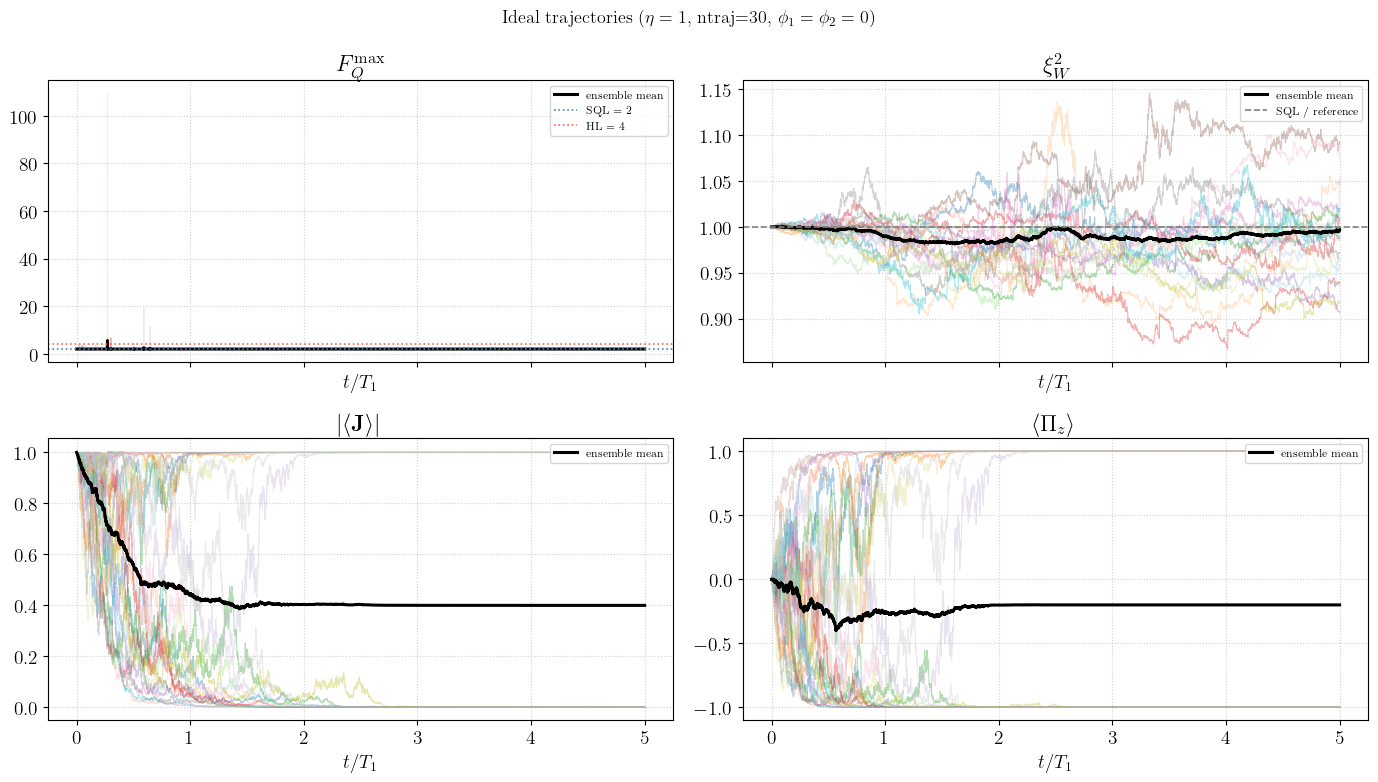

In [28]:
spaghetti_obs = ["QFI_max", "Xi2_WIN", "Norm_J", "Parity_Pi_z"]
spaghetti_labels = {
    "QFI_max":      r"$F_Q^{\max}$",
    "Xi2_WIN":      r"$\xi^2_W$",
    "Norm_J":       r"$|\langle\mathbf{J}\rangle|$",
    "Parity_Pi_z":  r"$\langle\Pi_z\rangle$",
}
hlines = {"Xi2_WIN": 1.0}          # reference lines at y=1
sql_hl  = {"QFI_max": (N_SPIN, N_SPIN**2)}   # (SQL, HL)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
cmap = plt.get_cmap("tab20", ntraj)

for ax, obs in zip(axes.flat, spaghetti_obs):
    # Individual trajectories
    for traj_idx in range(ntraj):
        sub = pure_traj_df[pure_traj_df.traj == traj_idx]
        ax.plot(sub["time"], sub[obs], color=cmap(traj_idx),
                alpha=0.35, linewidth=0.8)
    # Ensemble mean
    ax.plot(pure_ensemble_df["time"], pure_ensemble_df[obs],
            color="black", linewidth=2.2, label="ensemble mean")
    # Reference lines
    if obs in hlines:
        ax.axhline(hlines[obs], color="grey", linestyle="--", linewidth=1.2,
                   label="SQL / reference")
    if obs in sql_hl:
        ax.axhline(sql_hl[obs][0], color="steelblue", linestyle=":",
                   linewidth=1.2, label=f"SQL = {sql_hl[obs][0]}")
        ax.axhline(sql_hl[obs][1], color="tomato", linestyle=":",
                   linewidth=1.2, label=f"HL = {sql_hl[obs][1]}")
    ax.set_title(spaghetti_labels[obs])
    ax.set_xlabel(r"$t/T_1$")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(fontsize=8, loc="upper right")

plt.suptitle(
    rf"Ideal trajectories ($\eta=1$, ntraj={ntraj}, $\phi_1=\phi_2=0$)",
    fontsize=13
)
plt.tight_layout()
plt.savefig(OUT_DIR / "ideal_spaghetti.pdf", bbox_inches="tight")
plt.show()


### 3b. Ensemble mean ± 1σ ribbons

The shaded band shows ±1 standard deviation across trajectories at each time step.  A wide ribbon means high trajectory-to-trajectory variability; a narrow ribbon means the ensemble is self-averaging.


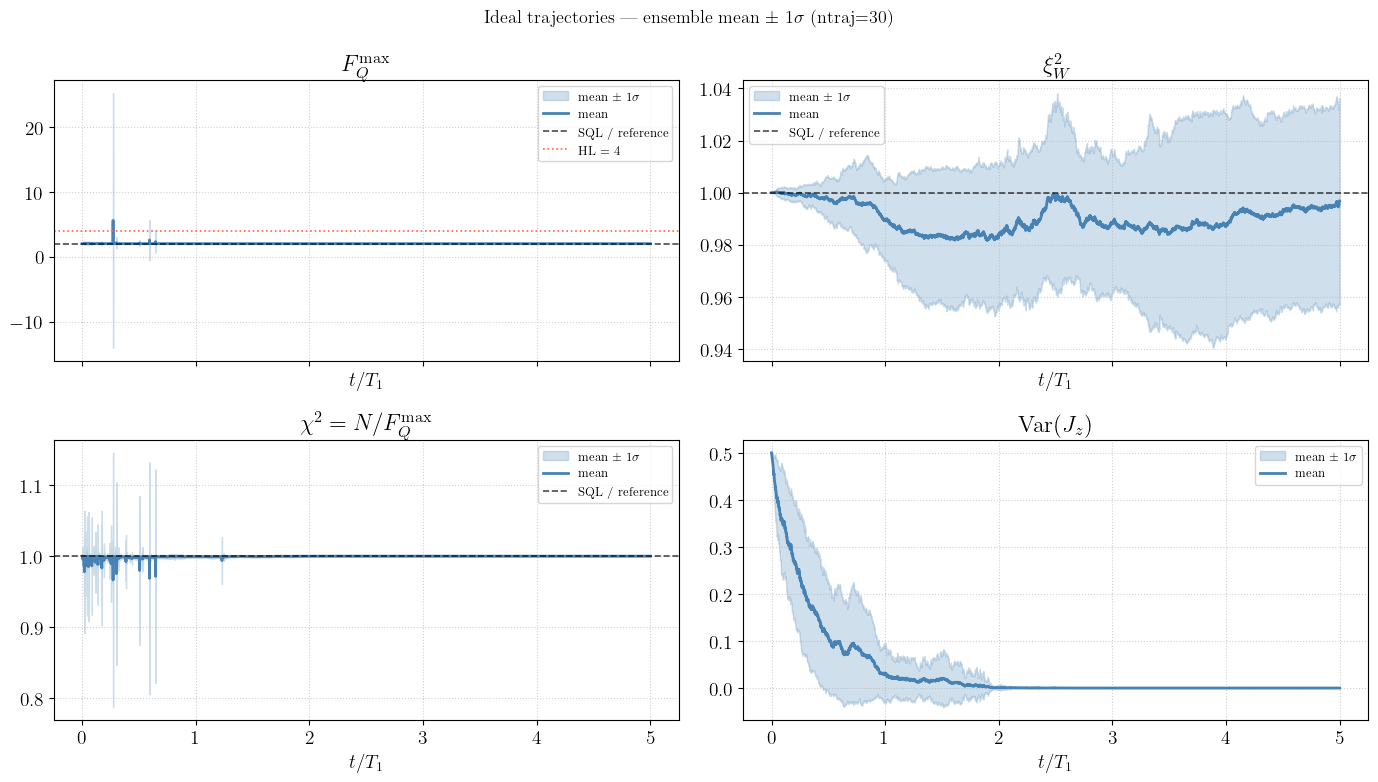

In [29]:
ribbon_obs = ["QFI_max", "Xi2_WIN", "chi_square", "Var_Jz"]
ribbon_labels = {
    "QFI_max":    r"$F_Q^{\max}$",
    "Xi2_WIN":    r"$\xi^2_W$",
    "chi_square": r"$\chi^2 = N/F_Q^{\max}$",
    "Var_Jz":     r"$\mathrm{Var}(J_z)$",
}
ribbon_refs = {"Xi2_WIN": 1.0, "chi_square": 1.0,
               "QFI_max": N_SPIN}          # SQL for QFI

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ax, obs in zip(axes.flat, ribbon_obs):
    mu  = pure_ribbon_df[obs].values
    sig = pure_ribbon_df[obs + "_std"].values
    t   = pure_ribbon_df["time"].values
    ax.fill_between(t, mu - sig, mu + sig, alpha=0.25, color="steelblue",
                    label=r"mean $\pm$ 1$\sigma$")
    ax.plot(t, mu, color="steelblue", linewidth=2, label="mean")
    if obs in ribbon_refs:
        ax.axhline(ribbon_refs[obs], color="black", linestyle="--",
                   linewidth=1.2, alpha=0.7, label="SQL / reference")
    if obs == "QFI_max":
        ax.axhline(N_SPIN**2, color="tomato", linestyle=":",
                   linewidth=1.2, label=f"HL = {N_SPIN**2}")
    ax.set_title(ribbon_labels[obs])
    ax.set_xlabel(r"$t/T_1$")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(fontsize=9)

plt.suptitle(
    rf"Ideal trajectories — ensemble mean $\pm$ 1$\sigma$  (ntraj={ntraj})",
    fontsize=13
)
plt.tight_layout()
plt.savefig(OUT_DIR / "ideal_ribbons.pdf", bbox_inches="tight")
plt.show()


### 3c. Final-time distributions

At $t = T_{\mathrm{end}}$ the 30 trajectories have spread across different conditional states.  The histograms show how the steady-state values of $F_Q^{\max}$ and $\xi^2_W$ are distributed across runs — revealing bimodality if the system settles into two distinct Bell-like attractors.


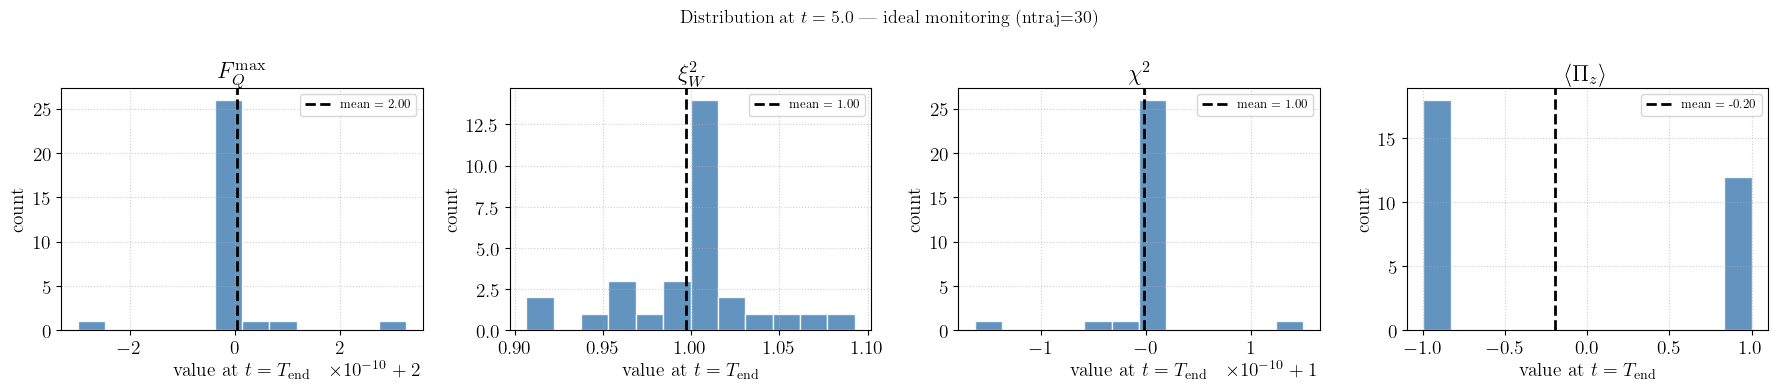


Final-time statistics (t = 5.0):
       QFI_max  Xi2_WIN  chi_square  Parity_Pi_z
count     30.0  30.0000        30.0      30.0000
mean       2.0   0.9968         1.0      -0.2000
std        0.0   0.0393         0.0       0.9965
min        2.0   0.9064         1.0      -1.0000
25%        2.0   0.9862         1.0      -1.0000
50%        2.0   1.0000         1.0      -1.0000
75%        2.0   1.0059         1.0       1.0000
max        2.0   1.0927         1.0       1.0000


In [30]:
t_final = times[-1]
final_df = pure_traj_df[np.isclose(pure_traj_df["time"], t_final)]

hist_obs = ["QFI_max", "Xi2_WIN", "chi_square", "Parity_Pi_z"]
hist_labels = {
    "QFI_max":      r"$F_Q^{\max}$",
    "Xi2_WIN":      r"$\xi^2_W$",
    "chi_square":   r"$\chi^2$",
    "Parity_Pi_z":  r"$\langle\Pi_z\rangle$",
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, obs in zip(axes, hist_obs):
    vals = final_df[obs].values
    ax.hist(vals, bins=12, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(vals.mean(), color="black", linewidth=2, linestyle="--",
               label=f"mean = {vals.mean():.2f}")
    ax.set_title(hist_labels[obs])
    ax.set_xlabel("value at $t = T_{\\mathrm{end}}$")
    ax.set_ylabel("count")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.6)

plt.suptitle(
    rf"Distribution at $t = {t_final:.1f}$ — ideal monitoring (ntraj={ntraj})",
    fontsize=13
)
plt.tight_layout()
plt.savefig(OUT_DIR / "ideal_final_histograms.pdf", bbox_inches="tight")
plt.show()

print(f"\nFinal-time statistics (t = {t_final:.1f}):")
print(final_df[hist_obs].describe().round(4).to_string())


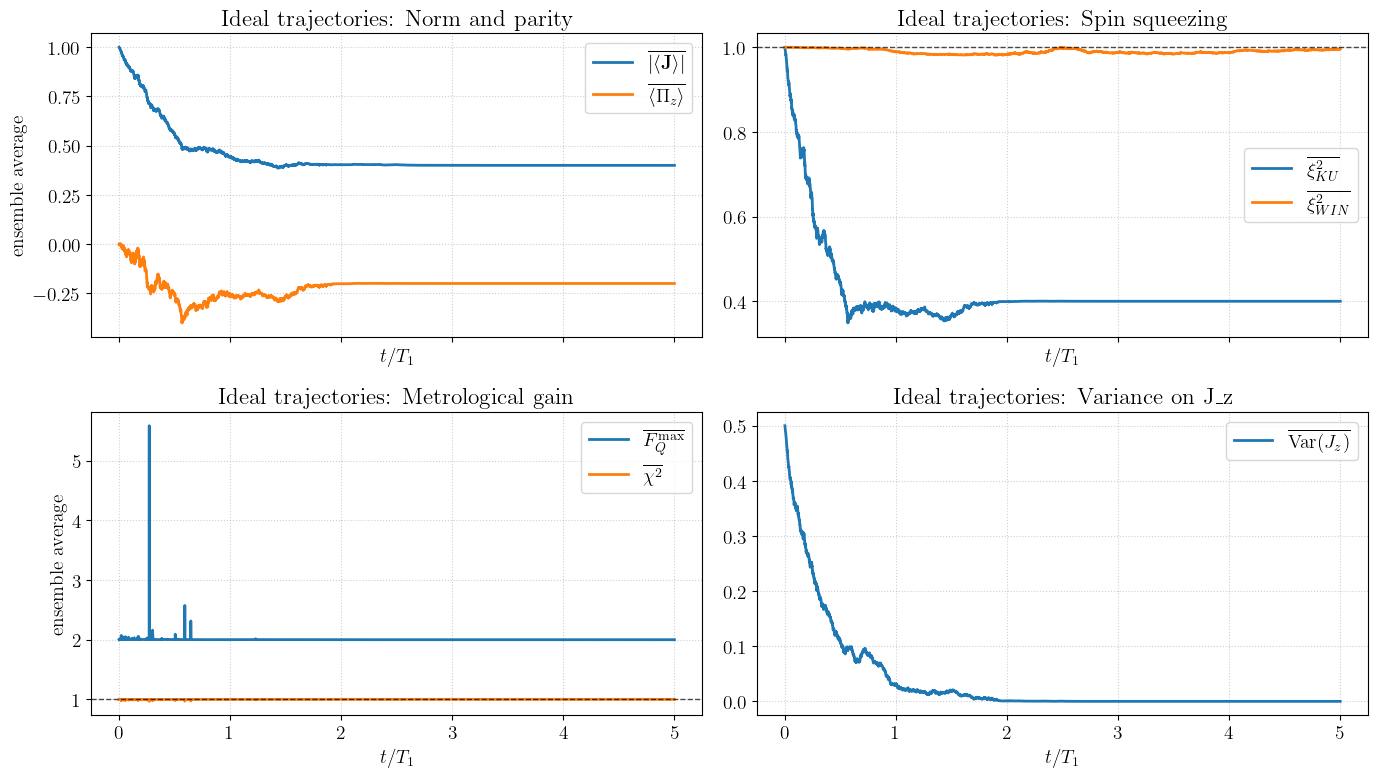

In [31]:
# Step 3 plots built directly from the DataFrames
plot_labels = {
    "Norm_J": r"$\overline{|\langle \mathbf{J} \rangle|}$",
    "Xi2_KU": r"$\overline{\xi^2_{KU}}$",
    "Xi2_WIN": r"$\overline{\xi^2_{WIN}}$",
    "QFI_max": r"$\overline{F_Q^{\max}}$",
    "chi_square": r"$\overline{\chi^2}$",
    "Var_Jz": r"$\overline{\mathrm{Var}(J_z)}$",
    "Parity_Pi_z": r"$\overline{\langle \Pi_z \rangle}$",
}
plot_groups = [
    ("Norm and parity", ["Norm_J", "Parity_Pi_z"]),
    ("Spin squeezing", ["Xi2_KU", "Xi2_WIN"]),
    ("Metrological gain", ["QFI_max", "chi_square"]),
    ("Variance on J_z", ["Var_Jz"]),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ax, (title, columns) in zip(axes.flat, plot_groups):
    for col in columns:
        df_obs = pure_plot_df[pure_plot_df["observable"] == col]
        ax.plot(df_obs["time"], df_obs["value"], linewidth=2, label=plot_labels[col])
    if any(col in {"Xi2_KU", "Xi2_WIN", "chi_square"} for col in columns):
        ax.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_title(f"Ideal trajectories: {title}")
    ax.set_xlabel(r"$t/T_1$")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend()

axes[0, 0].set_ylabel("ensemble average")
axes[1, 0].set_ylabel("ensemble average")

plt.tight_layout()
plt.savefig(OUT_DIR / "ideal_trajectories.pdf", bbox_inches="tight")
plt.show()

## 4. Mixed-state QFI — SLD formula

### Symmetric Logarithmic Derivative

For a mixed state $\rho = \sum_i p_i |i\rangle\langle i|$ the QFI with respect to a generator $G$ is given by the **SLD formula**:
$$
F_Q[\rho, G] = 2\sum_{\substack{i,j \\ p_i+p_j>0}} \frac{(p_i - p_j)^2}{p_i + p_j}\,|\langle i|G|j\rangle|^2.
$$

**Reduction to the pure case.**  If $\rho$ has rank 1 (say $p_0 = 1$, $p_{k>0} = 0$), the only surviving terms have $\{i,j\} = \{0,k\}$ with coefficient $2 \cdot 1^2/1 = 2$ each.  Summing both orderings gives $4\sum_{k>0}|\langle 0|G|k\rangle|^2 = 4(\langle G^2\rangle - \langle G\rangle^2) = 4\,\mathrm{Var}(G)$.  ✓

### Why mixed states matter here

When the detection efficiency is $\eta < 1$, the observer has *less information* than the environment.  Integrating over the unobserved noise produces a genuinely mixed conditional state.  For the same physical state, the SLD QFI is lower than the pure-state QFI — information is lost to the unmonitored channel.

The **mean state** $\bar\rho(t) = \mathbb{E}[\rho_c(t)]$ evolves according to the unconditional Lindblad equation; its QFI provides a *lower bound* on the average conditional QFI (by convexity of the QFI).


In [32]:
# -------------------------------------------------------------------------
# Nota: le funzioni mixed_state_qfi, mixed_qfi_matrix, mixed_optimal_axis_qfi
# e le interfacce unificate state_qfi_along_axis / state_optimal_axis_qfi
# sono gia' definite nel blocco Step 2 (pure-functions-code) e includono
# il caso puro come caso speciale.
#
# Verifica della riduzione puro -> misto su rho0 = |++><++| (rank 1):
#
#   Termini non nulli nella doppia somma: (0,k) e (k,0) con p_0=1, p_{k>0}=0
#   Coefficiente: 2*(1-0)^2/(1+0) = 2
#   Totale: 4 * sum_{k>0} |<0|G|k>|^2 = 4*(<G^2> - <G>^2) = 4 Var(G)  checkmark
# -------------------------------------------------------------------------

_check = {
    "4·Var(J_y)  [pura diretta]":      4.0 * float(variance(J_y, psi0)),
    "pure_optimal_axis_qfi(psi0)":      pure_optimal_axis_qfi(psi0)[0],
    "mixed_optimal_axis_qfi(rho0)":     mixed_optimal_axis_qfi(rho0)[0],
    "state_optimal_axis_qfi(psi0)":     state_optimal_axis_qfi(psi0)[0],
}
print("Consistency check — tutti i valori devono coincidere per |++>:")
for k, v in _check.items():
    print(f"  {k:45s}: {v:.10f}")

Consistency check — tutti i valori devono coincidere per |++>:
  4·Var(J_y)  [pura diretta]                   : 2.0000000000
  pure_optimal_axis_qfi(psi0)                  : 2.0000000000
  mixed_optimal_axis_qfi(rho0)                 : 2.0000000000
  state_optimal_axis_qfi(psi0)                 : 2.0000000000


In [33]:
mixed_qfi_xyz = {
    "J_x": mixed_qfi_along_axis(rho0, [1, 0, 0]),
    "J_y": mixed_qfi_along_axis(rho0, [0, 1, 0]),
    "J_z": mixed_qfi_along_axis(rho0, [0, 0, 1]),
}
mixed_qfi_opt, mixed_axis_opt, mixed_F_matrix = mixed_optimal_axis_qfi(rho0)

print("Mixed-state formula evaluated on rho0 = |++><++|:")
for label, value in mixed_qfi_xyz.items():
    print(f"  {label}: {value:.6f}")
print(f"  optimal QFI: {mixed_qfi_opt:.6f}")
print(f"  optimal axis: {np.round(mixed_axis_opt, 6)}")

Mixed-state formula evaluated on rho0 = |++><++|:
  J_x: 0.000000
  J_y: 2.000000
  J_z: 2.000000
  optimal QFI: 2.000000
  optimal axis: [-0.        0.981956 -0.189108]


## 5. Phase scan — effect of $\phi_1$ on metrological gain

The local measurement phase $\phi_1$ rotates the quadrature monitored on the $C_+$ channel.  At $\phi_1 = \pi/2$ the homodyne detector measures the *imaginary* quadrature of $C_+$, which is conjugate to the one at $\phi_1 = 0$.  This changes which observables are back-action noise squeezed and thus affects the long-time QFI.

Here we fix $\eta_1 = \eta_2 = 1$, $\phi_2 = 0$, and scan $\phi_1 \in \{0, \pi/4, \pi/2, 3\pi/4, \pi\}$ with `ntraj_scan = 15` trajectories each.  We compare the ensemble-averaged $F_Q^{\max}(t)$ and $\xi^2_W(t)$.


In [34]:
from fractions import Fraction

phi1_values  = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
phi1_labels  = [r"$0$", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"]
ntraj_scan   = 15
times_scan   = np.arange(0.0, T_END + 0.5 * DT, DT)

scan_results = {}   # phi1_val -> ensemble_df

for phi_val, phi_label in zip(phi1_values, phi1_labels):
    sol_scan = smesolve(
        H_free, rho0, times_scan,
        c_ops  = collapsing_operators(gamma, phi_val, 0.0, 0.0, 0.0),
        sc_ops = collapsing_operators(gamma, phi_val, 0.0, 1.0, 1.0),
        heterodyne=False, ntraj=ntraj_scan,
        options={"keep_runs_results": True, "num_cpus": 1, "map": "serial",
                 "store_measurement": False},
    )
    tdf = build_conditional_trajectory_df(
        sol_scan, times_scan,
        label=f"phi1={phi_label}", eta_1=1.0, eta_2=1.0,
    )
    scan_results[phi_label] = build_conditional_ensemble_df(tdf)
    print(f"  phi1 = {phi_label:>6s}  done  (ntraj={ntraj_scan})")

print("Phase scan complete.")


13.3%. Run time:   0.55s. Est. time left: 00:00:00:03
20.0%. Run time:   1.07s. Est. time left: 00:00:00:04
33.3%. Run time:   2.08s. Est. time left: 00:00:00:04
40.0%. Run time:   2.67s. Est. time left: 00:00:00:04
53.3%. Run time:   3.66s. Est. time left: 00:00:00:03
60.0%. Run time:   4.17s. Est. time left: 00:00:00:02
73.3%. Run time:   5.16s. Est. time left: 00:00:00:01
80.0%. Run time:   5.66s. Est. time left: 00:00:00:01
93.3%. Run time:   6.64s. Est. time left: 00:00:00:00
100.0%. Run time:   7.13s. Est. time left: 00:00:00:00
Total run time:   7.63s
  phi1 =    $0$  done  (ntraj=15)
13.3%. Run time:   0.50s. Est. time left: 00:00:00:03
20.0%. Run time:   1.01s. Est. time left: 00:00:00:04
33.3%. Run time:   4.67s. Est. time left: 00:00:00:09
40.0%. Run time:   5.37s. Est. time left: 00:00:00:08
53.3%. Run time:   6.39s. Est. time left: 00:00:00:05
60.0%. Run time:   6.92s. Est. time left: 00:00:00:04
73.3%. Run time:   7.91s. Est. time left: 00:00:00:02
80.0%. Run time:   8.41

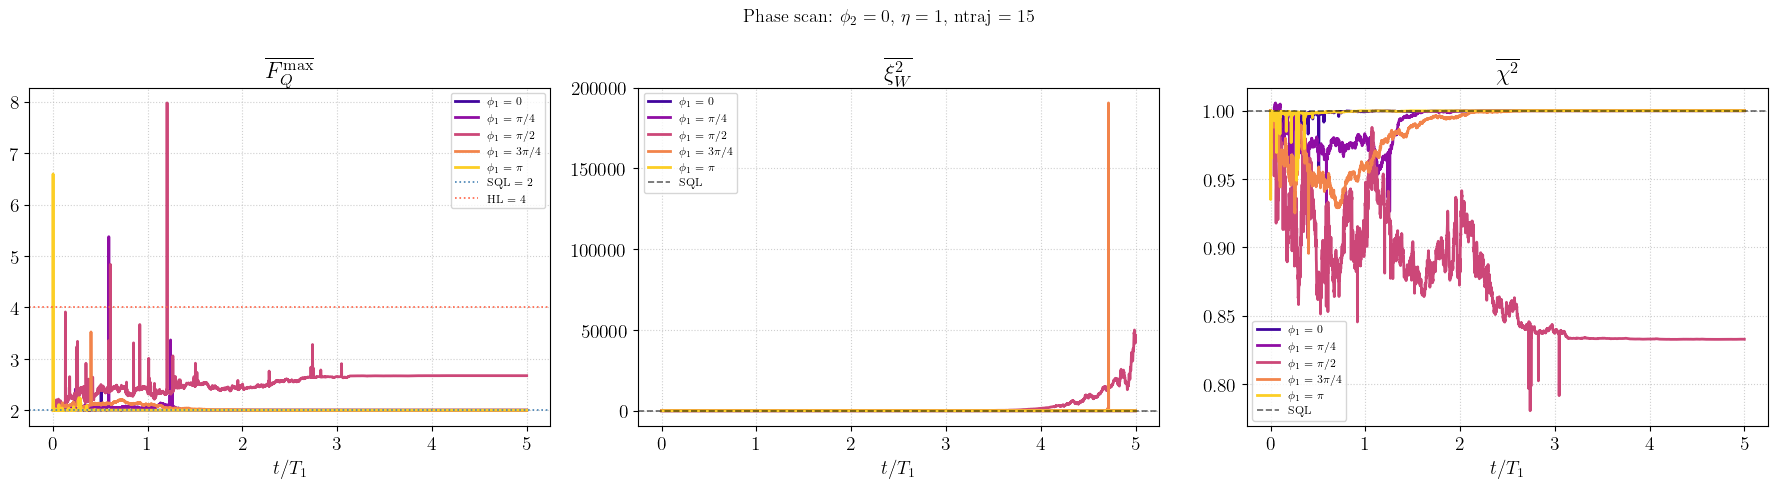


Final-time ensemble means across phi1 scan:
          QFI_max     Xi2_WIN   chi^2
phi1                                 
$0$        2.0000      1.0272  1.0000
$\pi/4$    2.0000      0.9696  1.0000
$\pi/2$    2.6715  46537.4883  0.8327
$3\pi/4$   2.0000      0.9852  1.0000
$\pi$      2.0000      0.9948  1.0000


In [35]:
colors_scan = plt.cm.plasma(np.linspace(0.1, 0.9, len(phi1_labels)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
scan_plot_obs = ["QFI_max", "Xi2_WIN", "chi_square"]
scan_plot_lbl = {
    "QFI_max":    r"$\overline{F_Q^{\max}}$",
    "Xi2_WIN":    r"$\overline{\xi^2_W}$",
    "chi_square": r"$\overline{\chi^2}$",
}

for ax, obs in zip(axes, scan_plot_obs):
    for (phi_label, edf), col in zip(scan_results.items(), colors_scan):
        ax.plot(edf["time"], edf[obs], linewidth=2,
                color=col, label=rf"$\phi_1 = $ {phi_label}")
    if obs in {"Xi2_WIN", "chi_square"}:
        ax.axhline(1.0, color="black", linestyle="--", linewidth=1.2, alpha=0.6,
                   label="SQL")
    if obs == "QFI_max":
        ax.axhline(N_SPIN,    color="steelblue", linestyle=":", linewidth=1.2,
                   label=f"SQL = {N_SPIN}")
        ax.axhline(N_SPIN**2, color="tomato",    linestyle=":", linewidth=1.2,
                   label=f"HL  = {N_SPIN**2}")
    ax.set_title(scan_plot_lbl[obs])
    ax.set_xlabel(r"$t/T_1$")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(fontsize=8)

plt.suptitle(
    rf"Phase scan: $\phi_2 = 0$, $\eta = 1$, ntraj = {ntraj_scan}",
    fontsize=13
)
plt.tight_layout()
plt.savefig(OUT_DIR / "phase_scan.pdf", bbox_inches="tight")
plt.show()

# Final-time summary table
print("\nFinal-time ensemble means across phi1 scan:")
rows = []
for phi_label, edf in scan_results.items():
    last = edf.iloc[-1]
    rows.append({"phi1": phi_label,
                 "QFI_max": last["QFI_max"],
                 "Xi2_WIN": last["Xi2_WIN"],
                 "chi^2":   last["chi_square"]})
print(pd.DataFrame(rows).set_index("phi1").round(4).to_string())


## 6. Efficiency scan — how $\eta$ degrades metrological gain

Reducing $\eta$ below 1 makes the conditional states genuinely mixed: part of the environment's measurement record is discarded.  The purity $\mathrm{Tr}(\rho_c^2)$ drops below 1, and the SLD QFI is strictly lower than the pure-state value.

We scan $\eta_1 = \eta_2 \equiv \eta \in \{1.0, 0.8, 0.6, 0.4\}$ with `ntraj_eta = 20` trajectories each, and for each $\eta$ we compare:
- the **trajectory-average** of $F_Q^{\max}$, $\xi^2_W$, purity;
- the **mean-state** QFI (lower bound).

**Key prediction:** as $\eta \to 0$ the conditional state converges to the unconditional Lindblad solution, the purity decays toward $1/4$ (maximally mixed for a 4-dim system), and $F_Q^{\max} \to F_Q[\bar\rho]$.


In [36]:
eta_values   = [1.0, 0.8, 0.6, 0.4]
ntraj_eta    = 20                          # trajectories per eta value
times_eta    = np.arange(0.0, T_END + 0.5 * DT, DT)

eta_traj_dfs      = {}   # eta -> trajectory-level DataFrame
eta_ensemble_dfs  = {}   # eta -> ensemble-average DataFrame
eta_meanstate_dfs = {}   # eta -> mean-state DataFrame

for eta in eta_values:
    sol_eta = smesolve(
        H_free, rho0, times_eta,
        c_ops  = collapsing_operators(gamma, 0.0, 0.0, 1.0 - eta, 1.0 - eta),
        sc_ops = collapsing_operators(gamma, 0.0, 0.0, eta, eta),
        heterodyne=False, ntraj=ntraj_eta,
        options={"keep_runs_results": True, "num_cpus": 1, "map": "serial",
                 "store_measurement": False},
    )
    tdf = build_conditional_trajectory_df(
        sol_eta, times_eta,
        label=f"eta={eta:.1f}", eta_1=eta, eta_2=eta,
    )
    # Add purity
    tdf["Purity"] = [
        purity(sol_eta.runs_states[r][t])
        for r in range(ntraj_eta)
        for t in range(len(times_eta))
    ]
    edf = build_conditional_ensemble_df(tdf)
    p_stats = tdf.groupby("time")["Purity"].mean().reset_index()
    p_stats.columns = ["time", "Purity_mean"]
    edf = edf.merge(p_stats, on="time", how="left")

    mdf = build_mean_state_observables_df(
        sol_eta, times_eta,
        label=f"eta={eta:.1f}", eta_1=eta, eta_2=eta,
    )

    eta_traj_dfs[eta]      = tdf
    eta_ensemble_dfs[eta]  = edf
    eta_meanstate_dfs[eta] = mdf
    print(f"  eta = {eta:.1f}  done  (ntraj={ntraj_eta})")

# Also keep eta=0.5 for the trajectory-mean vs mean-state comparison (Step 7)
eta_1_mixed, eta_2_mixed = 0.5, 0.5
ntraj_mixed = 20
sol_mixed = smesolve(
    H_free, rho0, times_eta,
    c_ops  = collapsing_operators(gamma, 0.0, 0.0, 0.5, 0.5),
    sc_ops = collapsing_operators(gamma, 0.0, 0.0, 0.5, 0.5),
    heterodyne=False, ntraj=ntraj_mixed,
    options={"keep_runs_results": True, "num_cpus": 1, "map": "serial",
             "store_measurement": False},
)
times_mixed = times_eta
print(f"\nEfficiency scan complete.  Also stored eta=0.5 run (ntraj={ntraj_mixed}).")


10.0%. Run time:   2.21s. Est. time left: 00:00:00:19
20.0%. Run time:   3.29s. Est. time left: 00:00:00:13
30.0%. Run time:   4.42s. Est. time left: 00:00:00:10
40.0%. Run time:   5.54s. Est. time left: 00:00:00:08
50.0%. Run time:   6.68s. Est. time left: 00:00:00:06
60.0%. Run time:   7.69s. Est. time left: 00:00:00:05
70.0%. Run time:   8.82s. Est. time left: 00:00:00:03
80.0%. Run time:   9.94s. Est. time left: 00:00:00:02
90.0%. Run time:  11.15s. Est. time left: 00:00:00:01
100.0%. Run time:  12.34s. Est. time left: 00:00:00:00
Total run time:  12.93s
  eta = 1.0  done  (ntraj=20)
10.0%. Run time:   0.55s. Est. time left: 00:00:00:04
20.0%. Run time:   1.57s. Est. time left: 00:00:00:06
30.0%. Run time:   2.57s. Est. time left: 00:00:00:05
40.0%. Run time:   3.57s. Est. time left: 00:00:00:05
50.0%. Run time:   7.45s. Est. time left: 00:00:00:07
60.0%. Run time:   8.45s. Est. time left: 00:00:00:05
70.0%. Run time:   9.47s. Est. time left: 00:00:00:04
80.0%. Run time:  10.47s. E

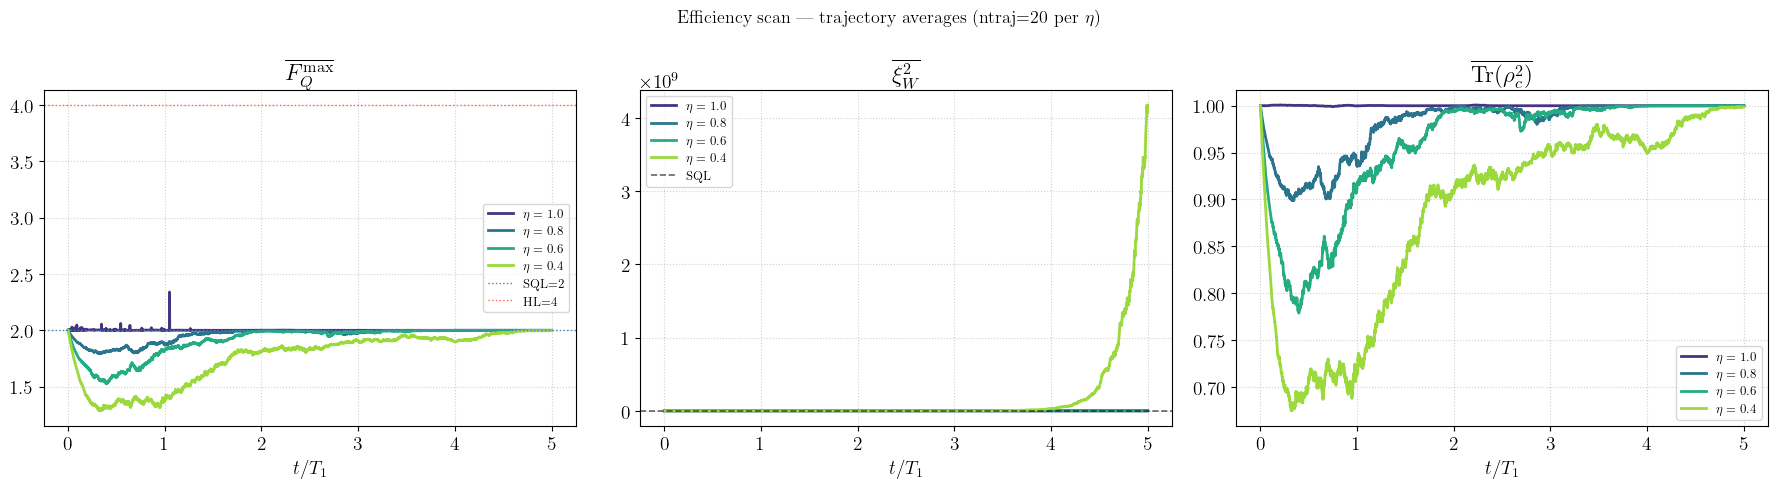

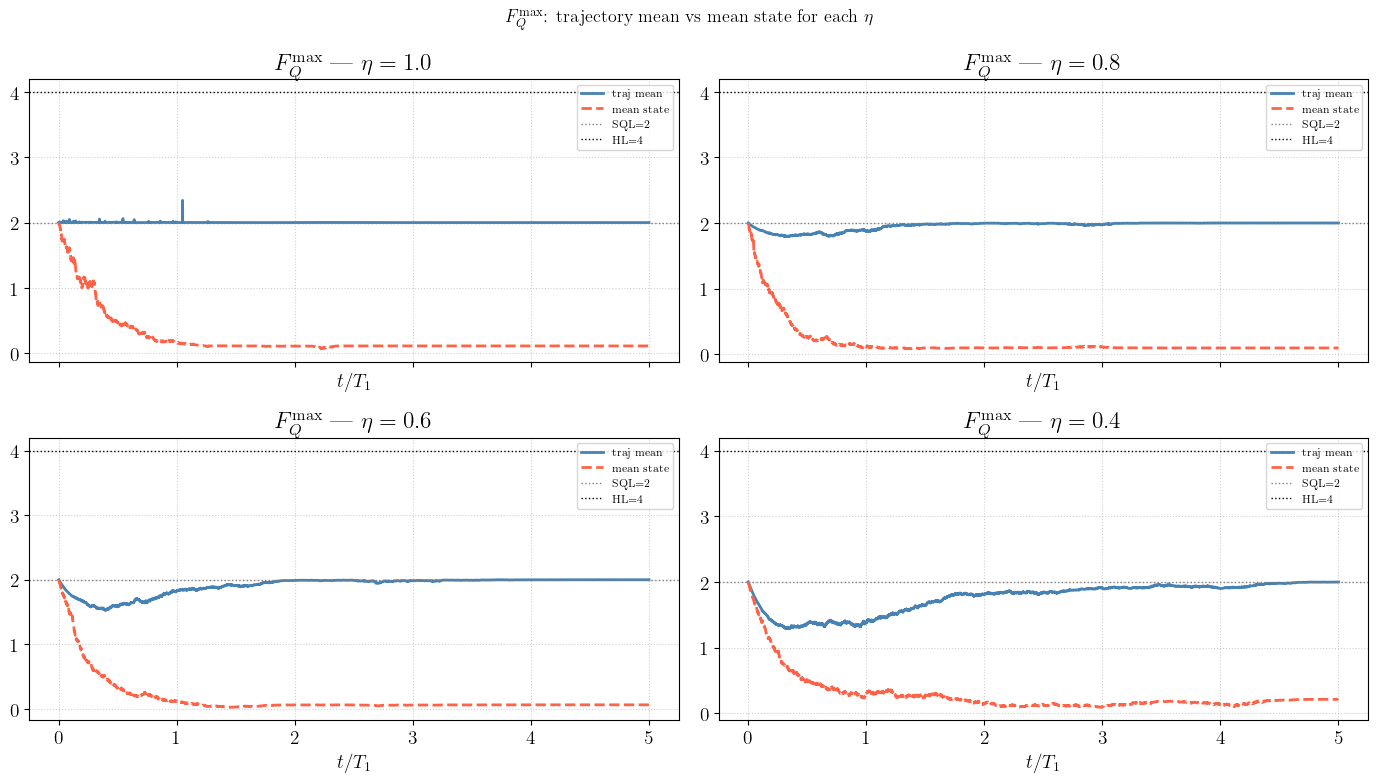

In [37]:
colors_eta = plt.cm.viridis(np.linspace(0.15, 0.85, len(eta_values)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
eta_plot_obs = ["QFI_max", "Xi2_WIN", "Purity_mean"]
eta_plot_lbl = {
    "QFI_max":     r"$\overline{F_Q^{\max}}$",
    "Xi2_WIN":     r"$\overline{\xi^2_W}$",
    "Purity_mean": r"$\overline{\mathrm{Tr}(\rho_c^2)}$",
}

for ax, obs in zip(axes, eta_plot_obs):
    for eta, col in zip(eta_values, colors_eta):
        edf = eta_ensemble_dfs[eta]
        ax.plot(edf["time"], edf[obs], linewidth=2,
                color=col, label=rf"$\eta = {eta:.1f}$")
    if obs in {"Xi2_WIN"}:
        ax.axhline(1.0, color="black", linestyle="--", linewidth=1.2, alpha=0.6,
                   label="SQL")
    if obs == "QFI_max":
        ax.axhline(N_SPIN,    color="steelblue", linestyle=":", linewidth=1,
                   label=f"SQL={N_SPIN}")
        ax.axhline(N_SPIN**2, color="tomato",    linestyle=":", linewidth=1,
                   label=f"HL={N_SPIN**2}")
    ax.set_title(eta_plot_lbl[obs])
    ax.set_xlabel(r"$t/T_1$")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(fontsize=9)

plt.suptitle(
    rf"Efficiency scan — trajectory averages  (ntraj={ntraj_eta} per $\eta$)",
    fontsize=13
)
plt.tight_layout()
plt.savefig(OUT_DIR / "efficiency_scan_traj.pdf", bbox_inches="tight")
plt.show()

# ── Trajectory mean vs mean-state for each eta ───────────────────────────────
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ax, eta in zip(axes2.flat, eta_values):
    edf = eta_ensemble_dfs[eta]
    mdf = eta_meanstate_dfs[eta]
    ax.plot(edf["time"], edf["QFI_max"], linewidth=2,
            label="traj mean", color="steelblue")
    ax.plot(mdf["time"], mdf["QFI_max"], linewidth=2, linestyle="--",
            label="mean state", color="tomato")
    ax.axhline(N_SPIN,    color="grey", linestyle=":", linewidth=1,
               label=f"SQL={N_SPIN}")
    ax.axhline(N_SPIN**2, color="black", linestyle=":", linewidth=1,
               label=f"HL={N_SPIN**2}")
    ax.set_title(rf"$F_Q^{{\max}}$ — $\eta = {eta:.1f}$")
    ax.set_xlabel(r"$t/T_1$")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(fontsize=8)

plt.suptitle(
    r"$F_Q^{\max}$: trajectory mean vs mean state for each $\eta$",
    fontsize=13
)
plt.tight_layout()
plt.savefig(OUT_DIR / "efficiency_scan_meanstate.pdf", bbox_inches="tight")
plt.show()


## 7. Comparison: trajectory mean vs mean state ($\eta = 0.5$)

With $\eta = 0.5$ the conditional state is genuinely mixed.  We compare two quantities:
- **trajectory mean**: $\mathbb{E}[O(\rho_c(t))]$ — average of the observable evaluated on each conditional state;
- **mean state**: $O(\bar\rho(t))$ — the observable evaluated on the averaged state.

By convexity of the QFI, $F_Q[\bar\rho] \leq \mathbb{E}[F_Q[\rho_c]]$, so the mean-state curve is always a lower bound on the trajectory-average curve.


In [38]:
# Build DataFrames for eta=0.5
mixed_traj_df = build_conditional_trajectory_df(
    sol_mixed, times_mixed,
    label="inefficient", eta_1=0.5, eta_2=0.5,
)
mixed_traj_df["Purity"] = [
    purity(sol_mixed.runs_states[r][t])
    for r in range(ntraj_mixed)
    for t in range(len(times_mixed))
]
mixed_ensemble_df = build_conditional_ensemble_df(mixed_traj_df)
mixed_mean_state_df = build_mean_state_observables_df(
    sol_mixed, times_mixed,
    label="inefficient", eta_1=0.5, eta_2=0.5,
)
mixed_compare_df = pd.concat([mixed_ensemble_df, mixed_mean_state_df], ignore_index=True)
mixed_compare_plot_df = mixed_compare_df.melt(
    id_vars=["time", "state_kind"],
    value_vars=OBSERVABLE_COLUMNS,
    var_name="observable", value_name="value",
)

compare_labels = {
    "trajectory_mean": "mean over conditional trajectories",
    "mean_state":      r"mean state $\bar{\rho}(t)$",
}
observable_labels = {
    "Norm_J":       r"$|\langle\mathbf{J}\rangle|$",
    "Xi2_KU":       r"$\xi^2_{KU}$",
    "Xi2_WIN":      r"$\xi^2_W$",
    "QFI_max":      r"$F_Q^{\max}$",
    "chi_square":   r"$\chi^2$",
    "Var_Jz":       r"$\mathrm{Var}(J_z)$",
    "Parity_Pi_z":  r"$\langle\Pi_z\rangle$",
}
compare_observables = ["QFI_max", "chi_square", "Xi2_WIN", "Var_Jz"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ax, obs in zip(axes.flat, compare_observables):
    df_obs = mixed_compare_plot_df[mixed_compare_plot_df["observable"] == obs]
    for state_kind, df_kind in df_obs.groupby("state_kind", sort=False):
        linestyle = "-" if state_kind == "trajectory_mean" else "--"
        ax.plot(df_kind["time"], df_kind["value"], linewidth=2,
                linestyle=linestyle, label=compare_labels[state_kind])
    if obs in {"Xi2_WIN", "chi_square"}:
        ax.axhline(1.0, color="black", linestyle=":", linewidth=1.2, alpha=0.7)
    if obs == "QFI_max":
        ax.axhline(N_SPIN,    color="steelblue", linestyle=":", linewidth=1)
        ax.axhline(N_SPIN**2, color="tomato",    linestyle=":", linewidth=1)
    ax.set_title(observable_labels[obs])
    ax.set_xlabel(r"$t/T_1$")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(fontsize=9)

plt.suptitle(
    rf"$\eta = 0.5$: trajectory mean vs mean state  (ntraj={ntraj_mixed})",
    fontsize=13
)
plt.tight_layout()
plt.savefig(OUT_DIR / "mixed_comparison.pdf", bbox_inches="tight")
plt.show()


KeyboardInterrupt: 

## 8. QFI vs spin-squeezing scatter

### Theoretical relationship

For a pure state and mean-spin direction $\hat{n}_J = \langle\mathbf{J}\rangle/|\langle\mathbf{J}\rangle|$, the Wineland parameter is
$$
\xi^2_W = \xi^2_{KU} \cdot \frac{(N/2)^2}{|\langle\mathbf{J}\rangle|^2},
$$
and $\xi^2_W < 1 \Leftrightarrow F_Q[J_\perp] > N$ for the best perpendicular axis.  However, $F_Q^{\max}$ optimises over *all* axes, not just the perpendicular to $\langle\mathbf{J}\rangle$, so the two quantities can diverge when the optimal metrological axis differs from the spin-squeezing axis.

The scatter below pools all (traj, time) points from all $\eta$ values and shows how $F_Q^{\max}$ correlates with $\xi^2_W$ and with the purity.


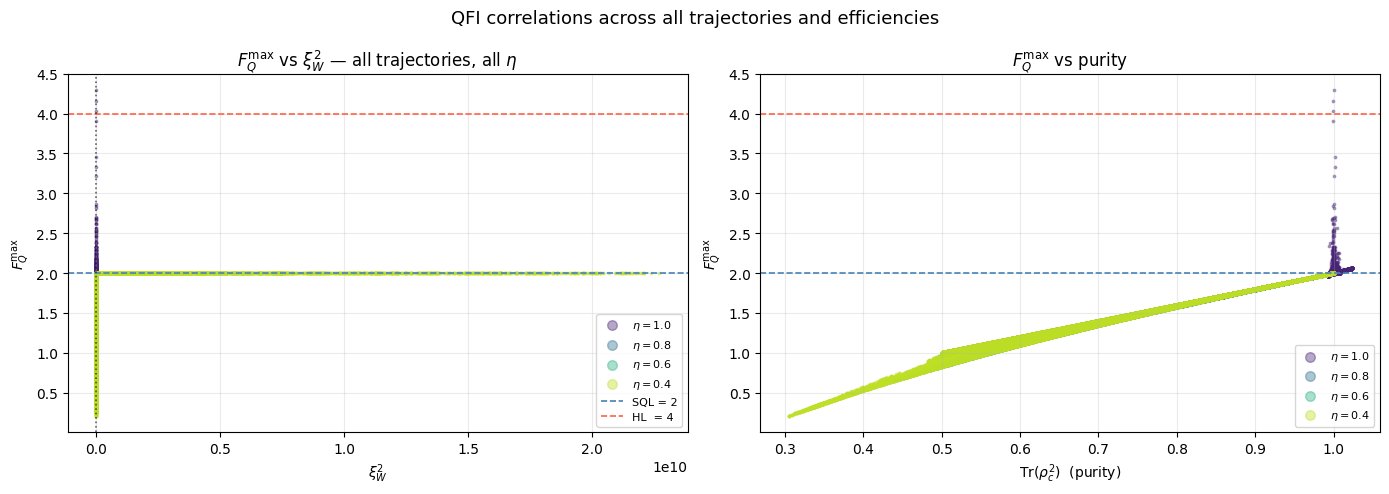

Total scatter points: 550110
      QFI_max                                                    Xi2_WIN                                                                           Purity                                               
        count   mean    std    min    25%    50%    75%    max     count          mean           std  min    25%    50%       75%           max     count   mean    std    min    25%    50%  75%    max
eta                                                                                                                                                                                                     
0.4  100020.0  1.735  0.381  0.208  1.531  1.973  1.999  2.000  100020.0  1.778630e+08  1.285846e+09  1.0  1.007  1.434    91.517  2.271539e+10  100020.0  0.876  0.172  0.305  0.772  0.987  1.0  1.000
0.6  100020.0  1.890  0.230  0.651  1.923  2.000  2.000  2.000  100020.0  2.163699e+05  8.863396e+05  1.0  1.001  2.653  1554.201  9.477428e+06  100020.0  0.947  0.109

In [ ]:
# Collect all trajectory points across eta scan
all_dfs = []
for eta in eta_values:
    sub = eta_traj_dfs[eta][["time", "QFI_max", "Xi2_WIN", "Norm_J", "Purity"]].copy()
    sub["eta"] = eta
    all_dfs.append(sub)
# Add the ideal run (eta=1 already in scan; add pure_traj_df for ntraj=30 statistics)
sub_ideal = pure_traj_df[["time", "QFI_max", "Xi2_WIN", "Norm_J", "Purity"]].copy()
sub_ideal["eta"] = 1.0
all_dfs.append(sub_ideal)
scatter_df = pd.concat(all_dfs, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_sc = plt.cm.viridis(np.linspace(0.1, 0.9, len(eta_values)))

# Left: QFI_max vs xi2_WIN
for eta, col in zip(eta_values, colors_sc):
    sub = scatter_df[scatter_df["eta"] == eta]
    axes[0].scatter(sub["Xi2_WIN"], sub["QFI_max"],
                    s=3, alpha=0.4, color=col, label=rf"$\eta={eta:.1f}$")

axes[0].axhline(N_SPIN,    color="steelblue", linestyle="--", linewidth=1.2,
                label=f"SQL = {N_SPIN}")
axes[0].axhline(N_SPIN**2, color="tomato",    linestyle="--", linewidth=1.2,
                label=f"HL  = {N_SPIN**2}")
axes[0].axvline(1.0, color="black", linestyle=":", linewidth=1.2, alpha=0.6)
axes[0].set_xlabel(r"$\xi^2_W$")
axes[0].set_ylabel(r"$F_Q^{\max}$")
axes[0].set_title(r"$F_Q^{\max}$ vs $\xi^2_W$ — all trajectories, all $\eta$")
axes[0].legend(fontsize=8, markerscale=4)
axes[0].grid(True, linestyle=":", alpha=0.6)

# Right: QFI_max vs Purity
for eta, col in zip(eta_values, colors_sc):
    sub = scatter_df[scatter_df["eta"] == eta]
    axes[1].scatter(sub["Purity"], sub["QFI_max"],
                    s=3, alpha=0.4, color=col, label=rf"$\eta={eta:.1f}$")

axes[1].axhline(N_SPIN,    color="steelblue", linestyle="--", linewidth=1.2)
axes[1].axhline(N_SPIN**2, color="tomato",    linestyle="--", linewidth=1.2)
axes[1].set_xlabel(r"$\mathrm{Tr}(\rho_c^2)$  (purity)")
axes[1].set_ylabel(r"$F_Q^{\max}$")
axes[1].set_title(r"$F_Q^{\max}$ vs purity")
axes[1].legend(fontsize=8, markerscale=4)
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.suptitle("QFI correlations across all trajectories and efficiencies", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "scatter_qfi_vs_squeezing.pdf", bbox_inches="tight")
plt.show()

print(f"Total scatter points: {len(scatter_df)}")
print(scatter_df.groupby("eta")[["QFI_max","Xi2_WIN","Purity"]].describe().round(3).to_string())


## 9. Reusable helpers and summary

All the building blocks defined in this notebook are self-contained and can be imported by other scripts.

| Helper | Description |
|--------|-------------|
| `pure_qfi_along_axis(psi, axis)` | $F_Q = 4\,\mathrm{Var}(J_n)$ for a pure ket |
| `pure_optimal_axis_qfi(psi)` | Returns $(F_Q^{\max}, n^*, \mathbf{F})$ via eigendecomposition |
| `mixed_state_qfi(rho, G)` | SLD QFI for a mixed state and generator $G$ |
| `mixed_optimal_axis_qfi(rho)` | Optimal QFI for a mixed state |
| `state_qfi_along_axis(state, axis)` | Unified interface (pure or mixed) |
| `state_optimal_axis_qfi(state)` | Unified interface (pure or mixed) |
| `purity(rho)` | $\mathrm{Tr}(\rho^2)$ |
| `build_conditional_trajectory_df(...)` | Per-(traj, time) DataFrame with all observables |
| `build_conditional_ensemble_df(traj_df)` | Trajectory average at fixed time |
| `build_mean_state_observables_df(...)` | Observables on $\bar\rho(t)$ |

### Figures produced

| File | Content |
|------|---------|
| `ideal_spaghetti.pdf` | 30 individual ideal trajectories |
| `ideal_ribbons.pdf` | Ensemble mean ± 1σ for ideal monitoring |
| `ideal_final_histograms.pdf` | Final-time distributions |
| `ideal_trajectories.pdf` | Standard 2×2 ensemble average plot |
| `phase_scan.pdf` | QFI and ξ² vs time for 5 phases |
| `efficiency_scan_traj.pdf` | QFI, ξ², purity for 4 efficiencies |
| `efficiency_scan_meanstate.pdf` | Trajectory mean vs mean state per η |
| `mixed_comparison.pdf` | Trajectory mean vs mean state (η=0.5) |
| `scatter_qfi_vs_squeezing.pdf` | $F_Q^{\max}$ vs $\xi^2_W$ and purity |


In [ ]:
def qfi_collective(state, axis):
    return state_qfi_along_axis(state, axis)


def optimal_collective_qfi(state):
    return state_optimal_axis_qfi(state)


print("Example QFI along J_y on |++><++|:", qfi_collective(rho0, [0, 1, 0]))
print(
    "Example optimized QFI on the first mixed trajectory state:",
    mixed_traj_df.loc[(mixed_traj_df["traj"] == 0) & (mixed_traj_df["time_idx"] == 0), "QFI_max"].iloc[0],
)
print("Example chi^2 at final mixed mean state:", mixed_mean_state_df["chi_square"].iloc[-1])
print(
    "Example optimal mixed mean-state axis at final time:",
    np.round(mixed_mean_state_df[AXIS_COLUMNS].iloc[-1].to_numpy(), 6),
)

Example QFI along J_y on |++><++|: 1.9999999999999984
Example optimized QFI on the first mixed trajectory state: 1.9999999999999984
Example chi^2 at final mixed mean state: 4.347827278909419
Example optimal mixed mean-state axis at final time: [0. 1. 0.]
